# Radiology AI Is Not Computer Vision — analysis notebook

This notebook reproduces the three figures in `main.md` and verifies that every
cited DOI resolves. The numbers are either physical (voxel geometry) or
illustrative stratification fractions anchored to the published size of
MIMIC-CXR (377,110 images). None of it requires the raw images; the point is the
arithmetic of subtlety and statistical power.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

FIG = "figures"
os.makedirs(FIG, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 150, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
})
NAVY, CRIMSON, STEEL, AMBER = "#1f3b57", "#9b1d20", "#3d7ca6", "#d99a00"

## Figure 1 — the needle in the haystack

How much of the image actually belongs to the finding? A $5\,$mm pulmonary
nodule is a sphere of volume $\tfrac{4}{3}\pi r^3 \approx 65\,$mm$^3 \approx 134$
voxels in an $\sim\!8.4\times10^7$-voxel chest CT — about one in 600,000.

3 mm nodule: 3.44e-07  (1 in 2,907,526 voxels)


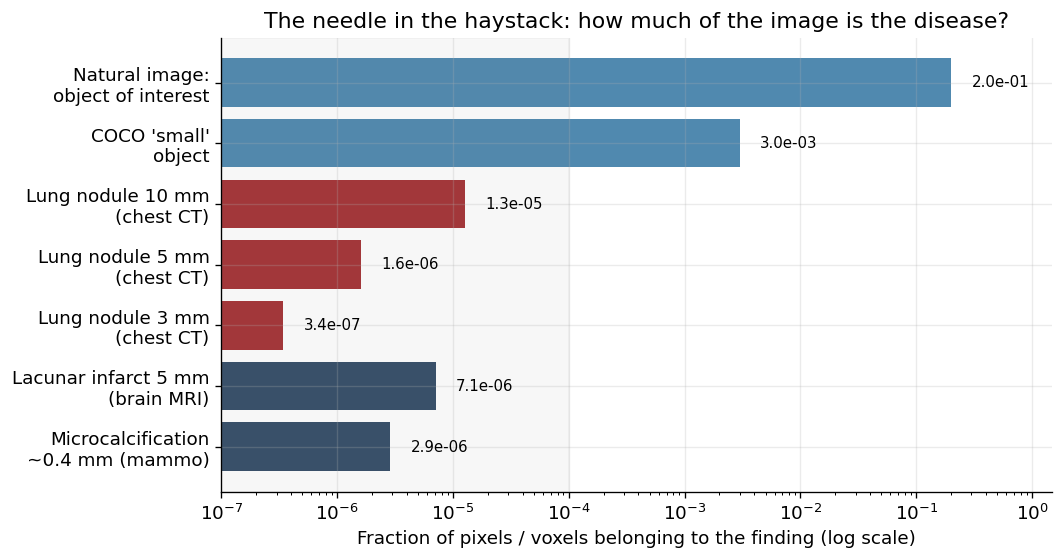

In [2]:
def sphere_volume(d_mm):
    r = d_mm / 2.0
    return (4.0 / 3.0) * np.pi * r ** 3  # mm^3

# Chest CT geometry (typical) and brain MRI (1 mm isotropic).
ct_total_vox = 512 * 512 * 320
ct_voxel_vol = 0.7 * 0.7 * 1.0
mri_total_vox = 240 * 240 * 160
mri_voxel_vol = 1.0
ct_frac = lambda d: sphere_volume(d) / ct_voxel_vol / ct_total_vox
mri_frac = lambda d: sphere_volume(d) / mri_voxel_vol / mri_total_vox

items = [
    ("Natural image:\nobject of interest", 0.20, STEEL),
    ("COCO 'small'\nobject", 0.003, STEEL),
    ("Lung nodule 10 mm\n(chest CT)", ct_frac(10), CRIMSON),
    ("Lung nodule 5 mm\n(chest CT)", ct_frac(5), CRIMSON),
    ("Lung nodule 3 mm\n(chest CT)", ct_frac(3), CRIMSON),
    ("Lacunar infarct 5 mm\n(brain MRI)", mri_frac(5), NAVY),
    ("Microcalcification\n~0.4 mm (mammo)", (0.4 / 0.07) ** 2 / (3000.0 * 3800.0), NAVY),
]
labels = [i[0] for i in items]
fracs = np.array([i[1] for i in items])
colors = [i[2] for i in items]

fig, ax = plt.subplots(figsize=(9, 4.8))
y = np.arange(len(items))[::-1]
ax.barh(y, fracs, color=colors, alpha=0.9)
ax.set_xscale("log"); ax.set_xlim(1e-7, 1.5)
ax.set_yticks(y); ax.set_yticklabels(labels)
ax.set_xlabel("Fraction of pixels / voxels belonging to the finding (log scale)")
for yi, f in zip(y, fracs):
    ax.text(f * 1.5, yi, f"{f:.1e}", va="center", ha="left", fontsize=9)
ax.axvspan(1e-7, 1e-4, color="grey", alpha=0.06)
ax.set_title("The needle in the haystack: how much of the image is the disease?")
fig.tight_layout(); fig.savefig(f"{FIG}/needle_in_haystack.png")
print(f"3 mm nodule: {ct_frac(3):.2e}  (1 in {1/ct_frac(3):,.0f} voxels)")

## Figure 2 — the stratification waterfall

Anchored to MIMIC-CXR (377,110 images). Each clinically reasonable filter
multiplies the count down; the *positive* cases collapse fastest because disease
is rare.

final evaluable positives = 66


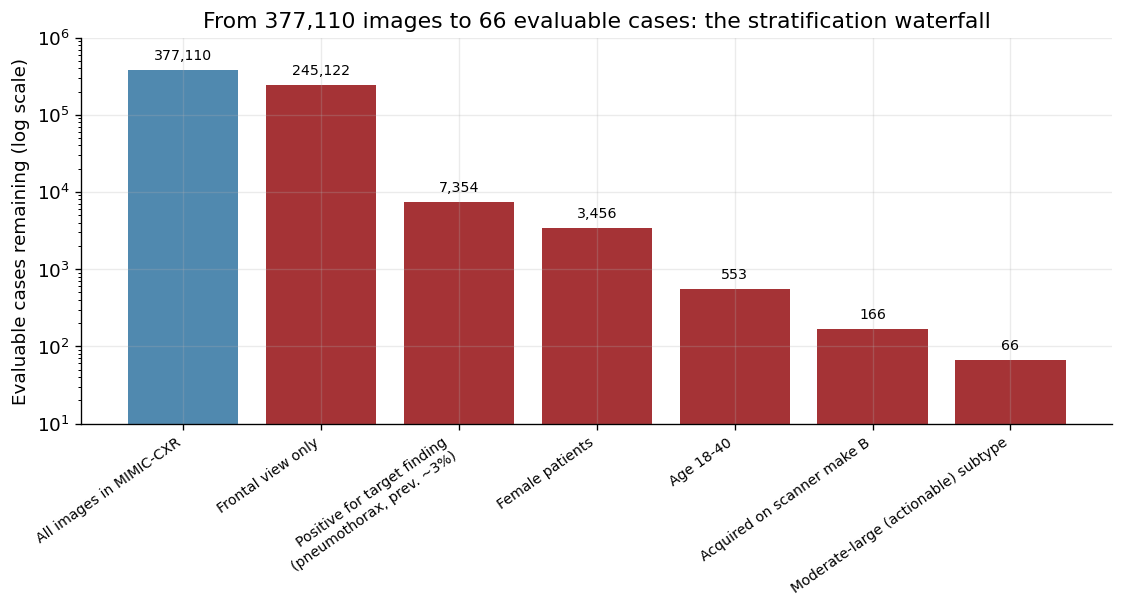

In [3]:
WATERFALL = [
    ("All images in MIMIC-CXR", 377_110),
    ("Frontal view only", 0.65),
    ("Positive for target finding\n(pneumothorax, prev. ~3%)", 0.03),
    ("Female patients", 0.47),
    ("Age 18-40", 0.16),
    ("Acquired on scanner make B", 0.30),
    ("Moderate-large (actionable) subtype", 0.40),
]
labels, counts, n = [], [], WATERFALL[0][1]
labels.append(WATERFALL[0][0]); counts.append(n)
for label, frac in WATERFALL[1:]:
    n *= frac; labels.append(label); counts.append(n)
counts = np.array(counts)

fig, ax = plt.subplots(figsize=(9.5, 5.2))
x = np.arange(len(counts))
ax.bar(x, counts, color=[STEEL] + [CRIMSON] * (len(counts) - 1), alpha=0.9)
ax.set_yscale("log"); ax.set_ylim(10, 1e6)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8.5)
ax.set_ylabel("Evaluable cases remaining (log scale)")
for xi, c in zip(x, counts):
    ax.text(xi, c * 1.25, f"{int(round(c)):,}", ha="center", va="bottom", fontsize=8.5)
ax.set_title("From 377,110 images to 66 evaluable cases: the stratification waterfall")
fig.tight_layout(); fig.savefig(f"{FIG}/stratification_waterfall.png")
print(f"final evaluable positives = {counts[-1]:.0f}")

## Figure 3 — precision and power

The CI half-width on a subgroup sensitivity shrinks only as $1/\sqrt{n}$, and
the power to detect a $0.85\to0.75$ gap needs ~250 positives/group for 80% — far
more than the deepest subgroup has.

required n/group for 80% power = 250
power at n=66 = 0.30
CI half-width at n=66 = 0.086


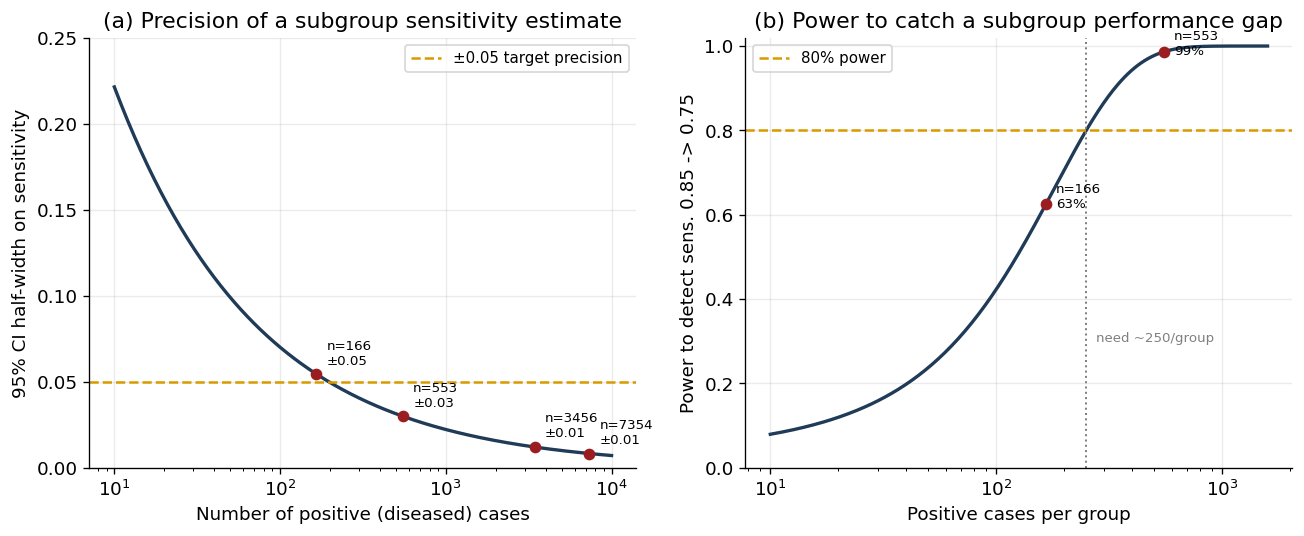

In [4]:
def ci_halfwidth(p, n, z=1.96):
    return z * np.sqrt(p * (1 - p) / n)

def power_two_prop(p1, p2, n, alpha=0.05):
    pbar = (p1 + p2) / 2.0
    z = norm.ppf(1 - alpha / 2.0)
    se0 = np.sqrt(2 * pbar * (1 - pbar) / n)
    se1 = np.sqrt(p1 * (1 - p1) / n + p2 * (1 - p2) / n)
    return norm.cdf((abs(p1 - p2) - z * se0) / se1)

def required_n(p1, p2, alpha=0.05, power=0.80):
    pbar = (p1 + p2) / 2.0
    za, zb = norm.ppf(1 - alpha / 2.0), norm.ppf(power)
    num = (za * np.sqrt(2 * pbar * (1 - pbar)) + zb * np.sqrt(p1*(1-p1)+p2*(1-p2)))**2
    return num / (p1 - p2) ** 2

p, p_drop = 0.85, 0.75
marks = list(zip(counts[2:], ["disease+", "+age", "+scanner", "+severity"]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
nn = np.logspace(1, 4, 300)
axes[0].plot(nn, ci_halfwidth(p, nn), color=NAVY, lw=2)
axes[0].axhline(0.05, color=AMBER, ls="--", lw=1.5, label="±0.05 target precision")
axes[0].set_xscale("log"); axes[0].set_ylim(0, 0.25)
axes[0].set_xlabel("Number of positive (diseased) cases")
axes[0].set_ylabel("95% CI half-width on sensitivity")
axes[0].set_title("(a) Precision of a subgroup sensitivity estimate")
for c, _ in marks:
    hw = ci_halfwidth(p, c); axes[0].plot([c], [hw], "o", color=CRIMSON)
    axes[0].annotate(f"n={int(round(c))}\n±{hw:.2f}", (c, hw),
                     textcoords="offset points", xytext=(6, 6), fontsize=8)
axes[0].legend(fontsize=9)

npg = np.logspace(1, 3.2, 300)
axes[1].plot(npg, [power_two_prop(p, p_drop, k) for k in npg], color=NAVY, lw=2)
axes[1].axhline(0.80, color=AMBER, ls="--", lw=1.5, label="80% power")
nreq = required_n(p, p_drop)
axes[1].axvline(nreq, color="grey", ls=":", lw=1.2)
axes[1].annotate(f"need ~{nreq:.0f}/group", (nreq, 0.3),
                 textcoords="offset points", xytext=(6, 0), fontsize=8, color="grey")
axes[1].set_xscale("log"); axes[1].set_ylim(0, 1.02)
axes[1].set_xlabel("Positive cases per group")
axes[1].set_ylabel("Power to detect sens. 0.85 -> 0.75")
axes[1].set_title("(b) Power to catch a subgroup performance gap")
for c, _ in marks:
    if c < 1100:
        pw = power_two_prop(p, p_drop, c); axes[1].plot([c], [pw], "o", color=CRIMSON)
        axes[1].annotate(f"n={int(round(c))}\n{pw:.0%}", (c, pw),
                         textcoords="offset points", xytext=(6, -2), fontsize=8)
axes[1].legend(fontsize=9)
fig.tight_layout(); fig.savefig(f"{FIG}/power_and_precision.png")
print(f"required n/group for 80% power = {nreq:.0f}")
print(f"power at n=66 = {power_two_prop(p, p_drop, 66):.2f}")
print(f"CI half-width at n=66 = {ci_halfwidth(p, 66):.3f}")

## Citation check

Per the blog's conventions, every cited DOI must resolve. This cell asks
`doi.org` (with BibTeX content negotiation) to resolve each DOI and prints the
status. It is network-dependent and wrapped so a build without internet does not
fail — it just reports what it could not reach.

In [5]:
import urllib.request

DOIS = {
    "TCIA (Clark 2013)": "10.1007/s10278-013-9622-7",
    "MIMIC-CXR (Johnson 2019)": "10.1038/s41597-019-0322-0",
    "CheXpert (Irvin 2019)": "10.1609/aaai.v33i01.3301590",
    "ChestX-ray8 (Wang 2017)": "10.1109/CVPR.2017.369",
    "PadChest (Bustos 2020)": "10.1016/j.media.2020.101797",
    "LIDC-IDRI (Armato 2011)": "10.1118/1.3528204",
    "BraTS-TCGA (Bakas 2017)": "10.1038/sdata.2017.117",
    "BraTS (Menze 2015)": "10.1109/TMI.2014.2377694",
    "fastMRI (Knoll 2020)": "10.1148/ryai.2020190007",
    "EMBED (Jeong 2023)": "10.1148/ryai.220047",
    "UK Biobank imaging (Littlejohns 2020)": "10.1038/s41467-020-15948-9",
    "Zech (2018)": "10.1371/journal.pmed.1002683",
    "AlBadawy (2018)": "10.1002/mp.12752",
}

def resolves(doi, timeout=10):
    req = urllib.request.Request(
        f"https://doi.org/{doi}",
        headers={"Accept": "application/x-bibtex", "User-Agent": "citation-check"},
    )
    try:
        with urllib.request.urlopen(req, timeout=timeout) as r:
            return r.status, r.geturl()
    except Exception as e:  # network-free builds land here
        return None, str(e)

ok = 0
for name, doi in DOIS.items():
    status, info = resolves(doi)
    flag = "OK " if status == 200 else "?? "
    ok += status == 200
    print(f"{flag} {name:<38} {doi:<32} {status if status else info[:40]}")
print(f"\n{ok}/{len(DOIS)} DOIs resolved (200).")

OK  TCIA (Clark 2013)                      10.1007/s10278-013-9622-7        200


OK  MIMIC-CXR (Johnson 2019)               10.1038/s41597-019-0322-0        200


OK  CheXpert (Irvin 2019)                  10.1609/aaai.v33i01.3301590      200


OK  ChestX-ray8 (Wang 2017)                10.1109/CVPR.2017.369            200


OK  PadChest (Bustos 2020)                 10.1016/j.media.2020.101797      200


...

OK  fastMRI (Knoll 2020)                   10.1148/ryai.2020190007          200


OK  EMBED (Jeong 2023)                     10.1148/ryai.220047              200


OK  UK Biobank imaging (Littlejohns 2020)  10.1038/s41467-020-15948-9       200


OK  Zech (2018)                            10.1371/journal.pmed.1002683     200


OK  AlBadawy (2018)                        10.1002/mp.12752                 200

13/13 DOIs resolved (200).
